<a href="https://colab.research.google.com/github/N-umwali/SchoolCare-Screening-Priority/blob/main/student_screening.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SchoolCare: Student Screening Model**
Survey C dataset is used to train the machine learning model to prioritise students for counsellor-led depression screening using 34 non-symptom predictors. This notebook reproduces the completed analysis with the original split, model settings and decision rules.

### **Step 1: Prepare Survey C**
The first cell locates the project folders, loads the original Excel file, and checks the expected 2,905 records and 56 columns.

**Import important libraries**

In [80]:
from pathlib import Path
import numpy as np
import pandas as pd
import json
import joblib
import sklearn
from IPython.display import display
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    roc_auc_score, recall_score, precision_score, f1_score
)
from sklearn.metrics import confusion_matrix


**Load Survey C
Load the dataset and create output folders.**

In [8]:
ROOT = Path("/content/SchoolCare-Screening-Priority")
RAW = ROOT / "data/raw"
DATA = ROOT / "data/processed"
REPORTS = ROOT / "reports"
FIGURES = REPORTS / "figures"
ARTIFACTS = ROOT / "model_artifacts"

for folder in (RAW, DATA, REPORTS, FIGURES, ARTIFACTS):
    folder.mkdir(parents=True, exist_ok=True)

source = RAW / "survey_c_reidentified.xlsx"

if not source.is_file():
    uploaded = files.upload()
    if source.name not in uploaded:
        raise FileNotFoundError("Upload survey_c_reidentified.xlsx.")
    source.write_bytes(uploaded[source.name])

raw = pd.read_excel(source)
assert raw.shape == (2905, 56), f"Unexpected data shape: {raw.shape}"
print("Original data shape:", raw.shape)

Original data shape: (2905, 56)


Survey C contains `2,905` records and `56` columns, as expected. Eligibility checks follow in the next cell.

**Identify eligible students**

A recorded school allows every student from that school to stay in the same evaluation partition. All eight PHQ responses are required to calculate the outcome.

### **Remove Missing School Codes**
Treat blank school codes as missing and retain students with a school code.

In [9]:
phq_cols = [f"PHQ_{i}" for i in range(1, 9)]

# Treat blank school codes as missing.
school = raw["school_name"].astype("string").str.strip().replace("", pd.NA)
missing_school = int(school.isna().sum())

with_school = raw.loc[school.notna()].copy()
with_school["school_name"] = school.loc[school.notna()]

### **Define the Outcome**
Retain complete PHQ-8 responses, validate scores, and label totals ≥10 as elevated symptoms. Confirm cohort counts.

In [10]:
# A complete PHQ-8 score needs all eight answers.
phq = with_school[phq_cols].apply(pd.to_numeric, errors="coerce")
incomplete_phq = int(phq.isna().any(axis=1).sum())

eligible = with_school.loc[phq.notna().all(axis=1)].copy()
valid_phq = phq.loc[eligible.index].isin([0, 1, 2, 3]).all().all()
assert valid_phq, "An eligible student has an invalid PHQ answer."

eligible["PHQ_sum"] = phq.loc[eligible.index].sum(axis=1).astype(int)
eligible["outcome"] = (eligible["PHQ_sum"] >= 10).astype(int)

assert missing_school == 654
assert incomplete_phq == 452
assert len(eligible) == 1799
assert eligible["school_name"].nunique() == 32

print(f"Original records: {len(raw)}")
print(f"Missing school: {missing_school}")
print(f"Incomplete PHQ-8 after school exclusion: {incomplete_phq}")
print(f"Eligible students: {len(eligible)}")
print(f"Schools: {eligible['school_name'].nunique()}")
print(f"Elevated PHQ-8 symptoms: {eligible['outcome'].sum()} "
      f"({eligible['outcome'].mean():.2%})")

Original records: 2905
Missing school: 654
Incomplete PHQ-8 after school exclusion: 452
Eligible students: 1799
Schools: 32
Elevated PHQ-8 symptoms: 535 (29.74%)


Of the `2,905` records, `654` had no school identifier. Among the remaining records, 452 had an incomplete PHQ-8 questionnaire.

**Check survey answer codes**

The approved predictors and attention-check answer are checked against their permitted codes. Undefined answers become missing without removing otherwise eligible students.

In [11]:
support = ["MSPSS_3", "MSPSS_4", "MSPSS_8", "MSPSS_11"]
strain = [f"FSS_{i}" for i in range(1, 5)]
aspirations = [f"AI_{i}" for i in range(1, 16)]

other = [
    "Age", "Gender", "Form", "Religion", "Surviving_Parents",
    "Parents_Dead", "Fathers_Education", "Mothers_Education",
    "Co_Curricular", "Sports", "Percieved_Academic_Abilities"
]
predictors = support + strain + aspirations + other
assert len(predictors) == len(set(predictors)) == 34

valid_codes = {
    **{col: set(range(1, 8)) for col in support + aspirations},
    **{col: set(range(1, 6)) for col in strain},
    "Gender": {1, 2},
    "Form": {1, 2, 3, 4},
    "Religion": set(range(1, 8)),
    "Surviving_Parents": {0, 1, 2},
    "Parents_Dead": {1, 2, 3, 4},
    "Fathers_Education": {1, 2, 3, 4},
    "Mothers_Education": {1, 2, 3, 4},
    "Co_Curricular": {1, 2, 3},
    "Sports": {1, 2},
    "Percieved_Academic_Abilities": {1, 2, 3, 4, 5},
    "GAD_Check": {0, 1, 2, 3},
}

### **Measure the undefined Religion code before changing it.**

In [22]:
# Recreate eligible students before cleaning.
phq_cols = [f"PHQ_{i}" for i in range(1, 9)]
phq = with_school[phq_cols].apply(pd.to_numeric, errors="coerce")

eligible = with_school.loc[phq.notna().all(axis=1)].copy()

assert phq.loc[eligible.index].isin([0, 1, 2, 3]).all().all(), (
    "An eligible student has an invalid PHQ answer."
)

eligible["PHQ_sum"] = phq.loc[eligible.index].sum(axis=1).astype(int)
eligible["outcome"] = (eligible["PHQ_sum"] >= 10).astype(int)

In [23]:
# Count undefined Religion codes before cleaning.
religion_code_8 = int(
    pd.to_numeric(eligible["Religion"], errors="coerce").eq(8).sum()
)

quality_rows = []

for col in predictors + ["GAD_Check"]:
    original = eligible[col]
    values = pd.to_numeric(original, errors="coerce")

    invalid_numeric = original.notna() & values.isna()

    # Age must be a positive whole number.
    invalid_age = (
        (col == "Age")
        & values.notna()
        & ((values <= 0) | (values % 1 != 0))
    )

    # Other columns must contain valid codebook values.
    invalid_code = (
        (col != "Age")
        & values.notna()
        & ~values.isin(valid_codes.get(col, []))
    )

    invalid = invalid_numeric | invalid_age | invalid_code
    eligible[col] = values.mask(invalid)

    quality_rows.append({
        "column": col,
        "invalid_codes": int(invalid.sum()),
        "missing_after_cleaning": int(eligible[col].isna().sum()),
        "missing_percent": round(100 * eligible[col].isna().mean(), 2),
    })

quality = pd.DataFrame(quality_rows)

assert religion_code_8 == 80, (
    f"Expected 80 Religion=8 values, found {religion_code_8}."
)
assert quality.set_index("column").loc["Religion", "invalid_codes"] == 80
assert quality.loc[
    quality["column"] != "Religion", "invalid_codes"
].sum() == 0

unusual_ages = (
    eligible["Age"].notna()
    & ~eligible["Age"].between(13, 21)
)

print("Undefined Religion=8 values set to missing:", religion_code_8)
print(
    "Ages outside the observed 13–21 range to review:",
    int(unusual_ages.sum())
)
display(quality)

Undefined Religion=8 values set to missing: 80
Ages outside the observed 13–21 range to review: 0


,column,invalid_codes,missing_after_cleaning,missing_percent
0,MSPSS_3,0,56,3.11
1,MSPSS_4,0,76,4.22
2,MSPSS_8,0,65,3.61
3,MSPSS_11,0,60,3.34
4,FSS_1,0,65,3.61
5,FSS_2,0,65,3.61
6,FSS_3,0,78,4.34
7,FSS_4,0,61,3.39
8,AI_1,0,50,2.78
9,AI_2,0,51,2.83


The codebook defines Religion codes `1–7`, but `80` eligible students had code `8`. Those answers were marked as missing while keeping the students in the dataset.

### **Separate inputs and save prepared data**

Only the `34` approved non-symptom predictors enter the model-input table. The school identifier is reserved for grouping and GAD_Check for the secondary sensitivity analysis.

In [31]:
# GAD_Check is kept only for the later sensitivity analysis.
failed_check = int(
    (eligible["GAD_Check"].notna() & eligible["GAD_Check"].ne(0)).sum()
)
blank_check = int(eligible["GAD_Check"].isna().sum())

assert failed_check == 188
assert blank_check == 181

X = eligible[predictors].copy()
y = eligible["outcome"].copy()
groups = eligible["school_name"].copy()

assert X.shape == (1799, 34)
assert X.columns.tolist() == predictors
assert X.index.equals(y.index) and X.index.equals(groups.index)
print("Approved model inputs:", X.shape)


Approved model inputs: (1799, 34)


In [32]:
prepared = eligible[
    predictors + ["outcome", "school_name", "GAD_Check"]
].copy()

exclusions = pd.DataFrame([
    ("Original records", len(raw)),
    ("Excluded: missing school", missing_school),
    ("Excluded next: incomplete PHQ-8", incomplete_phq),
    ("Eligible students", len(eligible)),
    ("Schools", eligible["school_name"].nunique()),
], columns=["measure", "count"])

prepared.to_csv(DATA / "survey_c_eligible.csv", index=False)
quality.to_csv(REPORTS / "step1_quality_report.csv", index=False)
exclusions.to_csv(REPORTS / "step1_exclusion_summary.csv", index=False)

print("Nonzero, nonblank GAD_Check:", failed_check)
print("Blank GAD_Check:", blank_check)
print("Saved: survey_c_eligible.csv")
print("Saved: step1_quality_report.csv")
print("Saved: step1_exclusion_summary.csv")

Nonzero, nonblank GAD_Check: 188
Blank GAD_Check: 181
Saved: survey_c_eligible.csv
Saved: step1_quality_report.csv
Saved: step1_exclusion_summary.csv


The model-input table has `1,799` students and exactly` 34` approved non-symptom predictors. The school identifier is reserved for splitting students by school; GAD_Check is retained only for a later sensitivity check.

### **Step 2: Describe the eligible students**

This step describes outcome balance, missing answers, student characteristics and response distributions. These summaries describe this survey sample; they do not identify causes or guide model selection.

### **PHQ-8 outcome balance***
The counts show the proportion of students in each questionnaire outcome group. This provides context for interpreting later recall and precision results.

In [43]:
counts = eligible["outcome"].value_counts().reindex([0, 1])
labels = ["Below PHQ-8 threshold", "Elevated PHQ-8 symptoms"]

print("Students in each outcome group:")
print(pd.DataFrame({
    "group": labels,
    "students": counts.values,
    "percent": (counts.values / len(eligible) * 100).round(1)
}))

Students in each outcome group:
                     group  students  percent
0    Below PHQ-8 threshold      1264     70.3
1  Elevated PHQ-8 symptoms       535     29.7


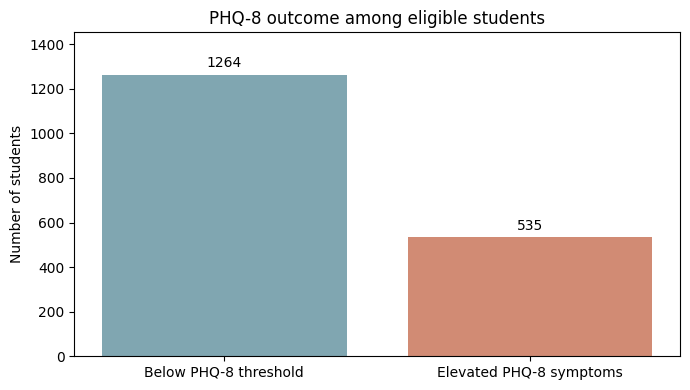

In [44]:
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, counts.values, color=["#80A6B1", "#D18B74"])
ax.bar_label(bars, padding=3)
ax.set_ylabel("Number of students")
ax.set_title("PHQ-8 outcome among eligible students")
ax.set_ylim(0, max(counts) * 1.15)
plt.tight_layout()
plt.savefig(FIGURES / "eda_outcome_balance.png", dpi=200, bbox_inches="tight")
plt.show()

Of the `1,799` eligible students, `1,264` `70.3%` scored below 10 on the PHQ-8, while 535 `29.7%` scored 10 or above. The elevated-symptom group is smaller, so accuracy alone would not be enough to judge a future model.

### **Missing answers by predictor**
The table and chart show which questions have the most missing answers. No values are filled during exploration; missing-value estimates belong inside the training pipeline.

Predictors with the most missing answers:


,missing_answers,missing_percent
Religion,166,9.2
Age,109,6.1
Fathers_Education,98,5.4
AI_14,79,4.4
FSS_3,78,4.3
MSPSS_4,76,4.2
Co_Curricular,73,4.1
Mothers_Education,73,4.1
FSS_2,65,3.6
MSPSS_8,65,3.6


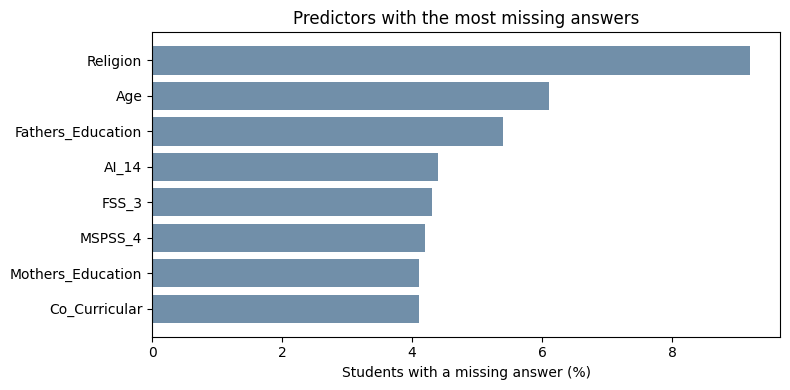

In [40]:
missing = X.isna().sum().sort_values(ascending=False)
missing_table = pd.DataFrame({
    "missing_answers": missing,
    "missing_percent": (missing / len(X) * 100).round(1)
})

print("Predictors with the most missing answers:")
display(missing_table.head(10))

fig, ax = plt.subplots(figsize=(8, 4))
top_missing = missing_table.head(8).sort_values("missing_percent")
ax.barh(top_missing.index, top_missing["missing_percent"], color="#718FA9")
ax.set_xlabel("Students with a missing answer (%)")
ax.set_title("Predictors with the most missing answers")
plt.tight_layout()
plt.savefig(FIGURES / "eda_missing_predictors.png", dpi=200, bbox_inches="tight")
plt.show()

Religion has the most missing answers: `166` students `9.2%`, including the `80` undefined codes changed to missing in Step 1. Age is missing for `109` students `6.1%`, and father's education is missing for `98` `5.4`.

Age and gender distribution
These summaries describe the students represented in the dataset and report missing demographic answers. The gender labels follow the survey codes: 1 for female and 2 for male.

In [41]:
age_groups = pd.cut(
    eligible["Age"],
    bins=[12, 15, 21],
    labels=["13–15", "16–21"]
)

gender_labels = eligible["Gender"].map({1: "Female", 2: "Male"})

print("Age groups, including missing age:")
display(age_groups.value_counts(dropna=False).rename("students").to_frame())

print("Gender, including missing gender:")
display(gender_labels.value_counts(dropna=False).rename("students").to_frame())

Age groups, including missing age:


,students
Age,
16–21,993
13–15,697
NaN,109


Gender, including missing gender:


,students
Gender,
Female,928
Male,813
NaN,58


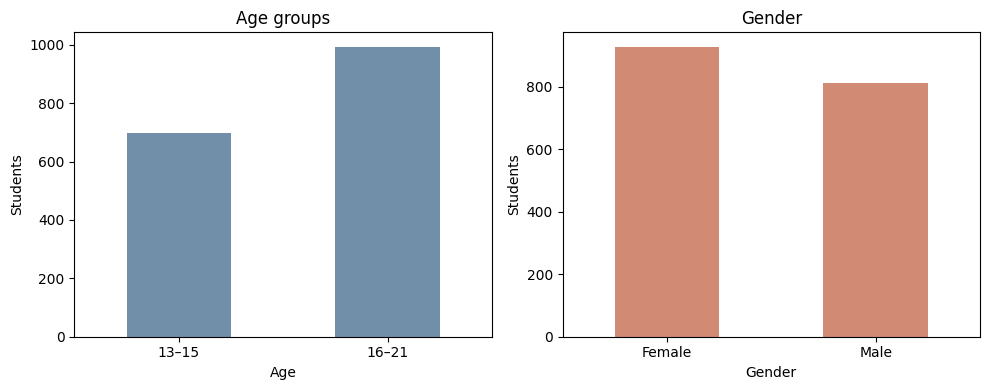

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

age_groups.value_counts().reindex(["13–15", "16–21"]).plot.bar(
    ax=axes[0], color="#718FA9", rot=0
)
axes[0].set_title("Age groups")
axes[0].set_ylabel("Students")

gender_labels.value_counts().reindex(["Female", "Male"]).plot.bar(
    ax=axes[1], color="#D18B74", rot=0
)
axes[1].set_title("Gender")
axes[1].set_ylabel("Students")

plt.tight_layout()
plt.savefig(FIGURES / "eda_age_gender.png", dpi=200, bbox_inches="tight")
plt.show()

Among students with a recorded age, `697` are aged `13–15` and `993` are aged `16–21`; `109` have no age recorded. The dataset contains `928` students coded female and `813` coded male, while `58` have no gender recorded.

### **Average responses within each factor**

Each student’s answered items are averaged within family support, financial strain and aspirations. The averages describe response patterns across PHQ-8 outcome groups and are not added as model predictors.

In [45]:
factor_items = {
    "Family support": support,
    "Financial strain": strain,
    "Aspirations": aspirations,
}

factor_means = pd.DataFrame({
    name: eligible[columns].mean(axis=1)
    for name, columns in factor_items.items()
})
factor_means["outcome"] = eligible["outcome"]

summary = factor_means.groupby("outcome").mean().T
summary.columns = ["Below PHQ-8 threshold", "Elevated PHQ-8 symptoms"]

print("Mean item response within each factor group:")
display(summary.round(2))

print("Students with at least one answered item in each factor:")
display(factor_means.drop(columns="outcome").notna().sum().rename("students").to_frame())

Mean item response within each factor group:


,Below PHQ-8 threshold,Elevated PHQ-8 symptoms
Family support,5.71,5.21
Financial strain,2.73,3.14
Aspirations,5.29,5.49


Students with at least one answered item in each factor:


,students
Family support,1761
Financial strain,1753
Aspirations,1796


In this sample, average family support is `5`.`71` in the below-threshold group and `5.21` in the elevated-symptom group. Average financial strain is `2.73` and `3.14`, respectively; average aspirations are `5.29` and `5.49`.

### **Students with incomplete predictor responses**
Counting students with at least one missing predictor shows the sample loss that complete-case analysis would cause. All 34 approved inputs are included in this check.

In [46]:
complete_students = int(X.notna().all(axis=1).sum())
students_with_missing = len(X) - complete_students

print(f"Students with all 34 predictors answered: {complete_students}")
print(f"Students missing at least one predictor: {students_with_missing}")
print(f"Share missing at least one predictor: {students_with_missing / len(X):.1%}")

assert complete_students == 1192
assert students_with_missing == 607

Students with all 34 predictors answered: 1192
Students missing at least one predictor: 607
Share missing at least one predictor: 33.7%


A total of `1,192` students `66.3%` answered all 34 predictors. The other `607` `33.7%` are missing at least one predictor answer.

### **PHQ-8 outcome by age and gender**
The tables report student counts and elevated-symptom shares for each group, including missing answers. These are descriptive survey summaries rather than measures of model performance.

In [47]:
age_group = pd.cut(
    eligible["Age"],
    bins=[12, 15, 21],
    labels=["13–15", "16–21"]
).astype("string").fillna("Age missing")

gender_group = eligible["Gender"].map({
    1: "Female", 2: "Male"
}).fillna("Gender missing")

In [48]:
def outcome_summary(groups):
    result = eligible.groupby(groups, dropna=False)["outcome"].agg(
        students="size",
        elevated="sum",
        elevated_share="mean"
    )
    result["elevated_share"] = (result["elevated_share"] * 100).round(1)
    return result

print("By gender:")
display(outcome_summary(gender_group))

print("By age:")
display(outcome_summary(age_group))

By gender:


,students,elevated,elevated_share
Gender,,,
Female,928,291,31.4
Gender missing,58,23,39.7
Male,813,221,27.2


By age:


,students,elevated,elevated_share
Age,,,
13–15,697,189,27.1
16–21,993,315,31.7
Age missing,109,31,28.4


The elevated PHQ-8 share is **31.4%** among students coded female and **27.2%** among students coded male. It is **27.1%** among students aged **13–15** and **31.7%** among those aged **16–21**.

### **Other student characteristics**
The table covers form, religion, parent information, activities, sports and perceived academic ability. Readable labels appear alongside the codes, counts and elevated-symptom shares.

In [49]:
characteristics = [
    "Form", "Religion", "Surviving_Parents", "Parents_Dead",
    "Fathers_Education", "Mothers_Education",
    "Co_Curricular", "Sports", "Percieved_Academic_Abilities"
]

tables = []

for column in characteristics:
    table = eligible.groupby(column, dropna=False)["outcome"].agg(
        students="size",
        elevated="sum",
        elevated_share="mean"
    ).reset_index()

    table.insert(0, "characteristic", column)
    table = table.rename(columns={column: "code"})
    table["code"] = table["code"].astype("string").fillna("Missing")
    table["elevated_share"] = (table["elevated_share"] * 100).round(1)
    tables.append(table)

characteristics_summary = pd.concat(tables, ignore_index=True)
# Give each survey code a readable label.
codebook_labels = {
    "Form": {1: "Form 1", 2: "Form 2", 3: "Form 3", 4: "Form 4"},
    "Religion": {
        1: "Christian Protestant", 2: "Christian Catholic",
        3: "Muslim", 4: "Buddhist", 5: "Traditional African",
        6: "No religion", 7: "Other"
    },
    "Surviving_Parents": {
        0: "No parents at home", 1: "One parent at home",
        2: "Both parents at home"
    },
    "Parents_Dead": {
        1: "Father", 2: "Mother", 3: "Both", 4: "Neither"
    },
    "Fathers_Education": {
        1: "Not aware", 2: "Primary", 3: "Secondary", 4: "University"
    },
    "Mothers_Education": {
        1: "Not aware", 2: "Primary", 3: "Secondary", 4: "University"
    },
    "Co_Curricular": {
        1: "Not involved", 2: "Quite involved", 3: "Extremely involved"
    },
    "Sports": {1: "No", 2: "Yes"},
    "Percieved_Academic_Abilities": {
        1: "Not satisfactory", 2: "Satisfactory", 3: "Good",
        4: "Very good", 5: "Excellent"
    }
}

In [50]:
def label_code(row):
    if pd.isna(row["code"]) or str(row["code"]) == "Missing":
        return "Missing"

    code = int(float(row["code"]))
    return codebook_labels[row["characteristic"]].get(
        code, "Check codebook"
    )

characteristics_summary["answer"] = characteristics_summary.apply(
    label_code, axis=1
)

display(characteristics_summary)
characteristics_summary.to_csv(
    REPORTS / "eda_student_characteristics.csv", index=False
)

,characteristic,code,students,elevated,elevated_share,answer
0,Form,1.0,674,174,25.8,Form 1
1,Form,2.0,519,159,30.6,Form 2
2,Form,3.0,308,94,30.5,Form 3
3,Form,4.0,250,90,36.0,Form 4
4,Form,Missing,48,18,37.5,Missing
5,Religion,1.0,975,283,29.0,Christian Protestant
6,Religion,2.0,504,147,29.2,Christian Catholic
7,Religion,3.0,76,16,21.1,Muslim
8,Religion,5.0,2,1,50.0,Traditional African
9,Religion,6.0,38,12,31.6,No religion


Students rating their academic ability "Not satisfactory" had a `42.6%` elevated PHQ-8 share `284` students, compared with `21.2%` among those rating it "Excellent" `325` students. Students living with no parents at home had a `45.8%` share `59` students, compared with `26.9%` among those living with both parents `1,098` students.

### **Differences between schools**
School summaries show the variation in eligible student counts and questionnaire outcomes. These descriptions explain the grouping structure without being used to choose test schools.

In [51]:
school_summary = eligible.groupby("school_name")["outcome"].agg(
    students="size",
    elevated="sum",
    elevated_share="mean"
)

school_summary["elevated_share"] = (
    school_summary["elevated_share"] * 100
).round(1)

print("Number of schools:", len(school_summary))
print("Students per school:",
      school_summary["students"].min(), "to",
      school_summary["students"].max())
print("Elevated PHQ-8 share per school:",
      school_summary["elevated_share"].min(), "% to",
      school_summary["elevated_share"].max(), "%")

school_summary.to_csv(REPORTS / "eda_school_summary.csv")

Number of schools: 32
Students per school: 2 to 141
Elevated PHQ-8 share per school: 0.0 % to 57.1 %


The `32` schools contribute between `2` and `141` eligible students each. Their elevated PHQ-8 shares range from `0%` to `57.1%`.

### **Variation within the factor groups**
Standard deviation describes how widely responses vary around each average. Comparisons stay within each factor because financial strain uses a different response scale from family support and aspirations.

In [52]:
factor_spread = factor_means.groupby("outcome").agg(
    family_support_mean=("Family support", "mean"),
    family_support_sd=("Family support", "std"),
    financial_strain_mean=("Financial strain", "mean"),
    financial_strain_sd=("Financial strain", "std"),
    aspirations_mean=("Aspirations", "mean"),
    aspirations_sd=("Aspirations", "std")
)

factor_spread.index = [
    "Below PHQ-8 threshold",
    "Elevated PHQ-8 symptoms"
]

display(factor_spread.round(2))
factor_spread.round(2).to_csv(REPORTS / "eda_factor_spread.csv")

,family_support_mean,family_support_sd,financial_strain_mean,financial_strain_sd,aspirations_mean,aspirations_sd
Below PHQ-8 threshold,5.71,1.36,2.73,0.93,5.29,0.99
Elevated PHQ-8 symptoms,5.21,1.48,3.14,0.92,5.49,0.89


The factor averages vary within both outcome groups. For example, family-support responses have standard deviations of about `1.36` below the PHQ-8 threshold and `1.48` in the elevated-symptom group.

### **Step 3: Restore the school split**
Every student from a school stays in the same partition. The original random seed and school allocation are retained, with seven schools reserved for the final evaluation.

### **Set aside about 20% of schools for the final test**


In [54]:
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()
groups_train = groups.iloc[train_idx].copy()
groups_test = groups.iloc[test_idx].copy()

### **Confirm that no school or student appears in both partitions**

In [55]:
assert len(X_train) + len(X_test) == 1799
assert set(groups_train).isdisjoint(set(groups_test))
assert set(train_idx).isdisjoint(set(test_idx))
assert X_train.index.equals(y_train.index)
assert X_test.index.equals(y_test.index)

split_summary = pd.DataFrame([
    {
        "partition": "Development",
        "schools": groups_train.nunique(),
        "students": len(y_train),
        "elevated_students": int(y_train.sum()),
        "elevated_share_percent": round(100 * y_train.mean(), 2)
    },
    {
        "partition": "Final test",
        "schools": groups_test.nunique(),
        "students": len(y_test),
        "elevated_students": int(y_test.sum()),
        "elevated_share_percent": round(100 * y_test.mean(), 2)
    }
])

display(split_summary)
split_summary.to_csv(REPORTS / "school_split_summary.csv", index=False)


,partition,schools,students,elevated_students,elevated_share_percent
0,Development,25,1438,438,30.46
1,Final test,7,361,97,26.87


### **Save the partition assigned to each eligible row**

In [56]:
split_membership = pd.DataFrame({
    "row_position": range(len(eligible)),
    "school_name": groups.to_numpy(),
    "partition": "Development"
})
split_membership.loc[test_idx, "partition"] = "Final test"
split_membership.to_csv(DATA / "school_split_membership.csv", index=False)

print("No schools shared between partitions:",
      set(groups_train).isdisjoint(set(groups_test)))
print("Saved: school_split_summary.csv")
print("Saved: school_split_membership.csv")
assert sorted(groups_test.unique()) == ["AI", "AJ", "G", "I", "P", "X", "Y"]
assert (len(X_train), len(X_test)) == (1438, 361)
assert (int(y_train.sum()), int(y_test.sum())) == (438, 97)

No schools shared between partitions: True
Saved: school_split_summary.csv
Saved: school_split_membership.csv


The development partition contains `1,438` students from `25` schools; `438` students `30.46%` have elevated PHQ-8 symptoms. The final test partition contains `361` students from seven schools; `97` students `26.87%` have elevated PHQ-8 symptoms.

Response correlations in development schools
The heatmap describes how family-support, financial-strain and aspiration responses vary together. Spearman correlation compares the ordering of responses, using available pairs of answers.

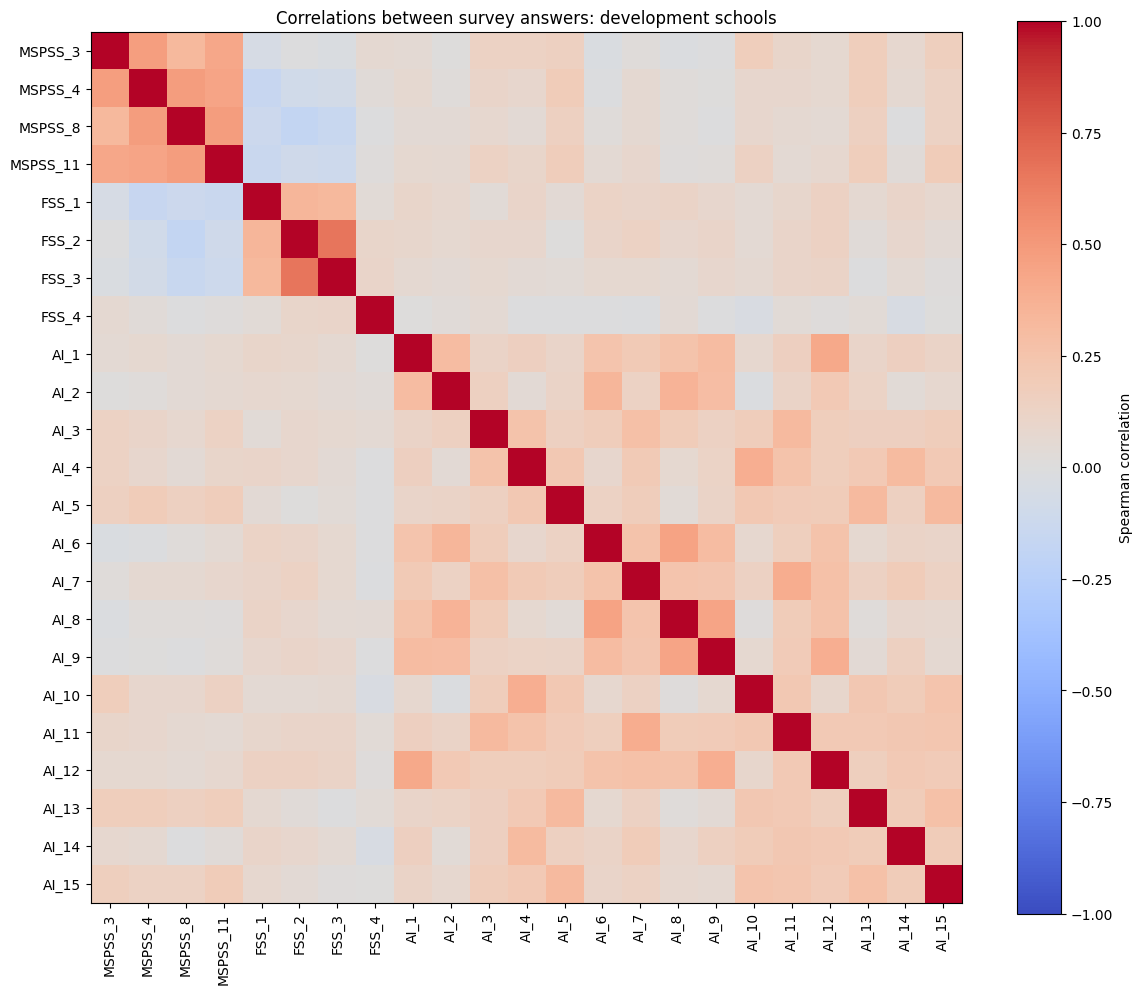

In [57]:
survey_columns = (
    [f"MSPSS_{i}" for i in [3, 4, 8, 11]]
    + [f"FSS_{i}" for i in range(1, 5)]
    + [f"AI_{i}" for i in range(1, 16)]
)

# Spearman correlation compares the ordering of coded responses.
correlations = X_train[survey_columns].corr(method="spearman")

fig, ax = plt.subplots(figsize=(12, 10))
image = ax.imshow(correlations, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(survey_columns)), survey_columns, rotation=90)
ax.set_yticks(range(len(survey_columns)), survey_columns)
ax.set_title("Correlations between survey answers: development schools")
fig.colorbar(image, ax=ax, label="Spearman correlation")

plt.tight_layout()
plt.savefig(FIGURES / "survey_question_correlations.png", dpi=200)
plt.show()

The development-school responses show some clustering within the family support, financial strain, and aspiration questions. The family support questions generally move together, while several financial strain answers show mild negative relationships with family support answers.

## **Step 4: Define preprocessing**
Missing numeric answers are filled with training medians and missing categorical answers with the most common training value. Categories become separate columns and numeric answers are scaled.

In [59]:
# These four answers are categories, even though their codes are numbers.
categorical_cols = [
    "Religion", "Parents_Dead",
    "Fathers_Education", "Mothers_Education"
]
numeric_cols = [col for col in predictors if col not in categorical_cols]

assert len(numeric_cols) == 30
assert len(categorical_cols) == 4
assert set(numeric_cols + categorical_cols) == set(predictors)
assert X_train.columns.tolist() == predictors
assert X_test.columns.tolist() == predictors

numeric_steps = Pipeline([
    ("fill_missing", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

categorical_steps = Pipeline([
    ("fill_missing", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(handle_unknown="ignore"))
])

In [60]:
# Any column outside these approved lists is dropped.
preprocessor = ColumnTransformer([
    ("numeric", numeric_steps, numeric_cols),
    ("categorical", categorical_steps, categorical_cols)
], remainder="drop")

# The transformed columns can be listed after fitting in Step 5.
print("Approved input columns (34):")
print(predictors)
print("\nNumeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))
print("Preprocessing fitted:", hasattr(preprocessor, "transformers_"))

Approved input columns (34):
['MSPSS_3', 'MSPSS_4', 'MSPSS_8', 'MSPSS_11', 'FSS_1', 'FSS_2', 'FSS_3', 'FSS_4', 'AI_1', 'AI_2', 'AI_3', 'AI_4', 'AI_5', 'AI_6', 'AI_7', 'AI_8', 'AI_9', 'AI_10', 'AI_11', 'AI_12', 'AI_13', 'AI_14', 'AI_15', 'Age', 'Gender', 'Form', 'Religion', 'Surviving_Parents', 'Parents_Dead', 'Fathers_Education', 'Mothers_Education', 'Co_Curricular', 'Sports', 'Percieved_Academic_Abilities']

Numeric columns: 30
Categorical columns: 4
Preprocessing fitted: False


The preprocessing rules cover all `34` approved non-symptom predictors: `30` numeric fields and four categorical fields. The pipeline has not been fitted, so it has not learned missing-value estimates, scaling values, or categories from any students.

**Step 5: Reproduce model comparison and selection**

The three models use the original school-aware validation and selection rules. Result notes describe the earlier run; use the original software version and check them against the new outputs.

In [70]:
# Use the same school-aware folds for all three models.
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
folds = list(cv.split(X_train, y_train, groups_train))

models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42
    )
}

fold_results = []
oof_probabilities = {}

for name, estimator in models.items():
    # Each student's prediction comes from a model that did not train on their school.
    probabilities = np.full(len(y_train), np.nan)

    for fold_number, (fit_idx, val_idx) in enumerate(folds, start=1):
        model = Pipeline([
            ("prepare", clone(preprocessor)),
            ("model", clone(estimator))
        ])

        model.fit(X_train.iloc[fit_idx], y_train.iloc[fit_idx])
        prob = model.predict_proba(X_train.iloc[val_idx])[:, 1]
        predicted = (prob >= 0.50).astype(int)
        actual = y_train.iloc[val_idx]

        probabilities[val_idx] = prob
        fold_results.append({
            "model": name,
            "fold": fold_number,
            "roc_auc": roc_auc_score(actual, prob),
            "recall": recall_score(actual, predicted, zero_division=0),
            "precision": precision_score(actual, predicted, zero_division=0),
            "f1": f1_score(actual, predicted, zero_division=0)
        })

    assert not np.isnan(probabilities).any()
    oof_probabilities[name] = probabilities

fold_results = pd.DataFrame(fold_results)

validation_summary = fold_results.groupby("model").agg(
    auc_mean=("roc_auc", "mean"),
    auc_sd=("roc_auc", "std"),
    recall_mean=("recall", "mean"),
    recall_sd=("recall", "std"),
    precision_mean=("precision", "mean"),
    precision_sd=("precision", "std"),
    f1_mean=("f1", "mean"),
    f1_sd=("f1", "std")
).sort_values("auc_mean", ascending=False)

display(validation_summary.round(3))
fold_results.to_csv(REPORTS / "step5_fold_results.csv", index=False)
validation_summary.to_csv(REPORTS / "step5_validation_summary.csv")

,auc_mean,auc_sd,recall_mean,recall_sd,precision_mean,precision_sd,f1_mean,f1_sd
model,,,,,,,,
Logistic Regression,0.658,0.021,0.611,0.041,0.408,0.051,0.488,0.046
Random Forest,0.642,0.033,0.059,0.041,0.392,0.114,0.101,0.061
Decision Tree,0.593,0.037,0.529,0.043,0.363,0.047,0.430,0.044


Logistic Regression had the highest mean ROC-AUC across five development-school validation folds `0.658`, `SD 0.021`. Random Forest followed at 0.642 `SD 0.033`, and the restricted Decision Tree reached `0.593` `SD 0.037`.

**Choose thresholds from development predictions**

Each model receives the highest threshold that achieves recall of at least 0.60 across its out-of-fold development predictions. These predictions come from models that did not train on the student’s school.

In [75]:
actual = y_train.to_numpy()
threshold_rows = []

for name, prob in oof_probabilities.items():
    # Try observed probabilities; choose the highest one meeting the recall rule.
    possible_thresholds = np.unique(prob)
    valid_thresholds = [
        value for value in possible_thresholds
        if recall_score(actual, prob >= value) >= 0.60
    ]
    threshold = float(max(valid_thresholds))
    predicted = (prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(actual, predicted, labels=[0, 1]).ravel()

    threshold_rows.append({
        "model": name,
        "threshold": threshold,
        "oof_roc_auc": roc_auc_score(actual, prob),
        "oof_recall": recall_score(actual, predicted),
        "oof_precision": precision_score(actual, predicted, zero_division=0),
        "oof_f1": f1_score(actual, predicted, zero_division=0),
        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp)
    })

threshold_summary = pd.DataFrame(threshold_rows).set_index("model")
locked_thresholds = threshold_summary["threshold"].to_dict()

In [79]:
# Select using mean fold ROC-AUC, as stated before looking at the results.
selected_name = validation_summary.index[0]
selected_threshold = locked_thresholds[selected_name]

display(threshold_summary.round(3))
print("Selected model:", selected_name)
print("Locked threshold:", round(selected_threshold, 4))
threshold_summary.to_csv(REPORTS / "step5_threshold_summary.csv")
# Stop before saving if the reproduced choice differs from the original run.
assert selected_name == "Logistic Regression", "Model choice differs: check the original environment."
assert round(selected_threshold, 4) == 0.5034, "Threshold differs: check the original scikit-learn version before saving."

,threshold,oof_roc_auc,oof_recall,oof_precision,oof_f1,true_negative,false_positive,false_negative,true_positive
model,,,,,,,,,
Logistic Regression,0.503,0.655,0.600,0.401,0.481,607,393,175,263
Decision Tree,0.447,0.597,0.614,0.356,0.451,513,487,169,269
Random Forest,0.315,0.634,0.600,0.409,0.487,620,380,175,263


Selected model: Logistic Regression
Locked threshold: 0.5034


Logistic Regression was selected by the predefined highest-mean-ROC-AUC rule. Its threshold was locked at `0.5034`.

### **Fit the development-school models**
Each candidate pipeline is fitted on all development students after validation and threshold selection. The transformed names are checked for excluded fields.

In [81]:
# Fit each revised model on all development schools.
fitted_models = {}

for name, estimator in models.items():
    pipeline = Pipeline([
        ("prepare", clone(preprocessor)),
        ("model", clone(estimator))
    ])
    pipeline.fit(X_train, y_train)
    fitted_models[name] = pipeline

selected_pipeline = fitted_models[selected_name]
feature_names = selected_pipeline.named_steps["prepare"].get_feature_names_out()

In [82]:
# Check that only approved answers became model features.
assert X_train.columns.tolist() == predictors
assert not any(
    banned in feature
    for feature in feature_names
    for banned in [
        "PHQ_", "GAD_", "school_name", "County",
        "todays_date", "interview_ok", "outcome"
    ]
)

print("Transformed feature names:")
print(feature_names.tolist())

Transformed feature names:
['numeric__MSPSS_3', 'numeric__MSPSS_4', 'numeric__MSPSS_8', 'numeric__MSPSS_11', 'numeric__FSS_1', 'numeric__FSS_2', 'numeric__FSS_3', 'numeric__FSS_4', 'numeric__AI_1', 'numeric__AI_2', 'numeric__AI_3', 'numeric__AI_4', 'numeric__AI_5', 'numeric__AI_6', 'numeric__AI_7', 'numeric__AI_8', 'numeric__AI_9', 'numeric__AI_10', 'numeric__AI_11', 'numeric__AI_12', 'numeric__AI_13', 'numeric__AI_14', 'numeric__AI_15', 'numeric__Age', 'numeric__Gender', 'numeric__Form', 'numeric__Surviving_Parents', 'numeric__Co_Curricular', 'numeric__Sports', 'numeric__Percieved_Academic_Abilities', 'categorical__Religion_1.0', 'categorical__Religion_2.0', 'categorical__Religion_3.0', 'categorical__Religion_5.0', 'categorical__Religion_6.0', 'categorical__Religion_7.0', 'categorical__Parents_Dead_1.0', 'categorical__Parents_Dead_2.0', 'categorical__Parents_Dead_3.0', 'categorical__Parents_Dead_4.0', 'categorical__Fathers_Education_1.0', 'categorical__Fathers_Education_2.0', 'categor

## **Random Forest importance**
Importance values describe how the forest used its inputs. They can favour inputs with many distinct values and are not evidence of causes.

In [83]:
# Report Random Forest feature importance.
rf_pipeline = fitted_models["Random Forest"]
rf_features = rf_pipeline.named_steps["prepare"].get_feature_names_out()

rf_importance = pd.DataFrame({
    "feature": rf_features,
    "importance": rf_pipeline.named_steps["model"].feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop 15 Random Forest features:")
display(rf_importance.head(15))
rf_importance.to_csv(
    REPORTS / "step5_rf_feature_importance.csv", index=False
)


Top 15 Random Forest features:


,feature,importance
4,numeric__FSS_1,0.052974
2,numeric__MSPSS_8,0.043249
29,numeric__Percieved_Academic_Abilities,0.042799
3,numeric__MSPSS_11,0.039916
13,numeric__AI_6,0.039143
23,numeric__Age,0.039106
16,numeric__AI_9,0.037181
9,numeric__AI_2,0.036118
15,numeric__AI_8,0.036029
7,numeric__FSS_4,0.035774


The highest-ranked forest inputs in the earlier run included serious financial worries, family support and perceived academic ability. Verify the saved importance table against the new output; importance does not establish causation.

## **Logistic Regression coefficients**
The table reports signed coefficients and ranks their absolute size. Categorical coefficients, especially those for rare categories, require cautious interpretation.

In [84]:
# Report Logistic Regression coefficients for interpretation.
lr_pipeline = fitted_models["Logistic Regression"]
lr_features = lr_pipeline.named_steps["prepare"].get_feature_names_out()

lr_coefficients = pd.DataFrame({
    "feature": lr_features,
    "coefficient": lr_pipeline.named_steps["model"].coef_[0]
})
lr_coefficients["absolute_coefficient"] = (
    lr_coefficients["coefficient"].abs()
)
lr_coefficients = lr_coefficients.sort_values(
    "absolute_coefficient", ascending=False
)

print("\nTop 15 Logistic Regression coefficients by absolute size:")
display(lr_coefficients.head(15))
lr_coefficients.to_csv(
    REPORTS / "step5_logistic_coefficients.csv", index=False
)


Top 15 Logistic Regression coefficients by absolute size:


,feature,coefficient,absolute_coefficient
38,categorical__Parents_Dead_3.0,0.595763,0.595763
4,numeric__FSS_1,0.387674,0.387674
33,categorical__Religion_5.0,0.366466,0.366466
32,categorical__Religion_3.0,-0.296008,0.296008
36,categorical__Parents_Dead_1.0,-0.288686,0.288686
35,categorical__Religion_7.0,0.288210,0.288210
44,categorical__Mothers_Education_1.0,0.259712,0.259712
3,numeric__MSPSS_11,-0.255395,0.255395
18,numeric__AI_11,0.248503,0.248503
29,numeric__Percieved_Academic_Abilities,-0.236955,0.236955


The earlier fit included large coefficients for serious financial worries and some parent and religion categories. Rare categories can produce unstable estimates.

## **Confirm the reserved schools**
The school list is checked against the original allocation. This check prevents a changed partition from being mistaken for a reproduction.

In [85]:
# Record the schools reserved for the final test.
final_test_schools = sorted(groups_test.unique().tolist())
assert final_test_schools == ["AI", "AJ", "G", "I", "P", "X", "Y"]
print("\nFinal test schools:", final_test_schools)


Final test schools: ['AI', 'AJ', 'G', 'I', 'P', 'X', 'Y']


The printed school list matches the original seven-school allocation.

## **Save pipelines and metadata**
The fitted pipelines, full-precision thresholds, input order and software version are saved together. These files provide the scoring setup used by the dashboard.

In [86]:
# Preserve existing artifacts; verify reproduction before replacing them.
existing_metadata = ARTIFACTS / "step5_locked_details.json"
if existing_metadata.exists():
    with open(existing_metadata) as file:
        original_details = json.load(file)
    assert original_details["scikit_learn_version"] == sklearn.__version__, "Use the original scikit-learn version."
    assert original_details["selected_model"] == selected_name
    assert np.isclose(original_details["selected_threshold"], selected_threshold, rtol=0, atol=1e-10), "The original full-precision threshold differs."

In [87]:
# Save the models and choices made before testing.
joblib.dump(
    selected_pipeline, ARTIFACTS / "selected_pipeline.joblib"
)
joblib.dump(
    fitted_models, ARTIFACTS / "candidate_pipelines.joblib"
)

locked_details = {
    "selected_model": selected_name,
    "selected_threshold": selected_threshold,
    "candidate_thresholds": locked_thresholds,
    "approved_input_columns": predictors,
    "scikit_learn_version": sklearn.__version__,
    "split_random_state": 42,
    "final_test_schools": final_test_schools,
    "model_settings_note": (
        "Before final testing, all three models used balanced class weights; "
        "Decision Tree used min_samples_leaf=20."
    )
}

with open(ARTIFACTS / "step5_locked_details.json", "w") as file:
    json.dump(locked_details, file, indent=2)

print("\nSaved revised models, thresholds, feature reports, and input list.")
print("Final test schools scored: No")


Saved revised models, thresholds, feature reports, and input list.
Final test schools scored: No


The saved files contain the selected pipeline, the candidate pipelines and their locked metadata. Final-test scoring follows in Step 6; sensitivity models do not replace the primary artifact.

The revised models use 48 transformed features from the 34 approved non-symptom predictors, with no banned fields in the feature list. In the Random Forest, FSS_1, MSPSS_8, and perceived academic ability have the highest feature importance values.

## **Numeric coefficients in the selected model**
The chart shows the largest numeric coefficients in the fitted Logistic Regression model. Numeric inputs were scaled, making their sizes more comparable.

In [92]:
questions = {
    "MSPSS_3": "My family really tries to help me",
    "MSPSS_4": "I get the emotional help and support I need from my family",
    "MSPSS_8": "I can talk about my problems with my family",
    "MSPSS_11": "My family is willing to help me make decisions",
    "FSS_1": "Do you have serious financial worries?",
    "FSS_2": "Are you unable to do things you like because of shortages of money?",
    "FSS_3": "Are you unable to do things you need because of shortages of money?",
    "FSS_4": "Are you unable to manage the money you have?",
    "AI_1": "How important is it to be rich?",
    "AI_2": "How important is it to be famous?",
    "AI_3": "How important is it to have good friends you can count on?",
    "AI_4": "How important is it to be physically healthy?",
    "AI_5": "How important is it to work to make the world a better place?",
    "AI_6": "How important is it to be admired by many people?",
    "AI_7": "How important is it to share your life with someone you love?",
    "AI_8": "How important is it that people comment on your attractiveness?",
    "AI_9": "How important is it to keep up with fashions in hair and clothing?",
    "AI_10": "How important is it to know and accept who you really are?",
    "AI_11": "How important is it to love and be loved by others?",
    "AI_12": "How important is it to have enough money to buy everything you want?",
    "AI_13": "How important is it to help people in need?",
    "AI_14": "How important is it to be relatively free from sickness?",
    "AI_15": "How important is it to grow and learn new things?",
    "Age": "How old is the student?",
    "Gender": "What is the student's gender?",
    "Form": "Which form is the student in?",
    "Religion": "What is the student's religion or spirituality?",
    "Surviving_Parents": "How many parents does the student live with at home?",
    "Parents_Dead": "Have any of the student's parents passed away?",
    "Fathers_Education": "What is the father's highest level of education?",
    "Mothers_Education": "What is the mother's highest level of education?",
    "Co_Curricular": "Is the student involved in clubs or societies?",
    "Sports": "Is the student part of a school sports team?",
    "Percieved_Academic_Abilities": "How does the student rate their academic performance?",
}
# Use the saved primary model; do not fit or change it.
pipeline = joblib.load(ARTIFACTS / "selected_pipeline.joblib")
feature_names = pipeline.named_steps["prepare"].get_feature_names_out()
coefficients = pipeline.named_steps["model"].coef_[0]

weights = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
})

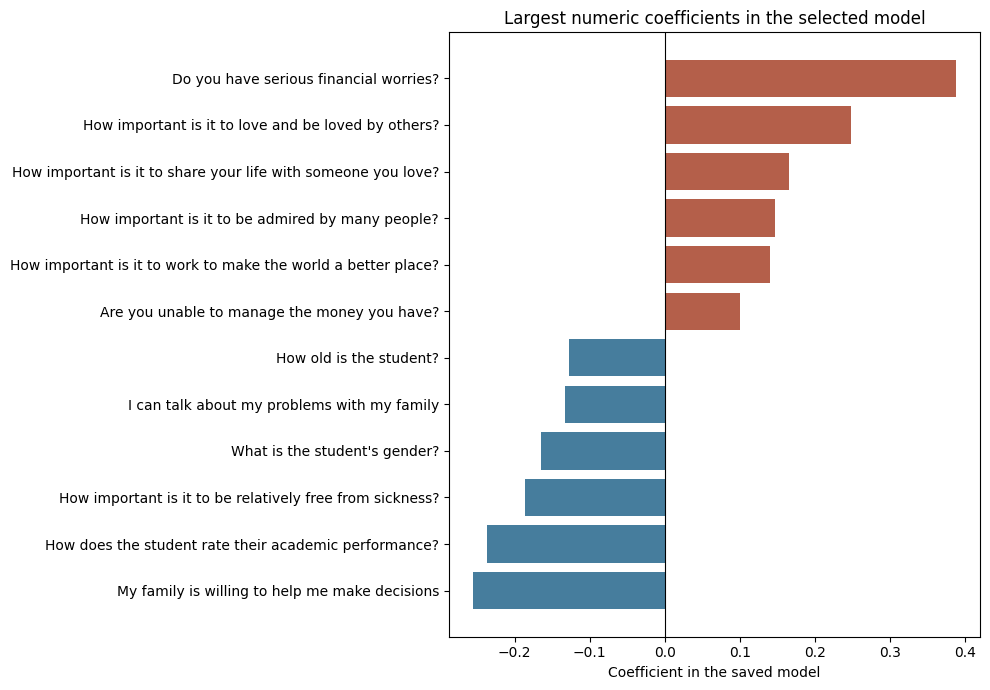

In [93]:
# Numeric inputs were scaled, making their coefficient sizes more comparable.
numeric_weights = weights[
    weights["feature"].str.startswith("numeric__")
].copy()

numeric_weights["column"] = numeric_weights["feature"].str.replace(
    "numeric__", "", regex=False
)
numeric_weights["question"] = numeric_weights["column"].map(questions)
numeric_weights["size"] = numeric_weights["coefficient"].abs()

top_weights = numeric_weights.nlargest(12, "size").sort_values("coefficient")

fig, ax = plt.subplots(figsize=(10, 7))
colors = np.where(top_weights["coefficient"] >= 0, "#B45F4A", "#467D9D")

ax.barh(top_weights["question"], top_weights["coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient in the saved model")
ax.set_title("Largest numeric coefficients in the selected model")

plt.tight_layout()
plt.savefig(FIGURES / "selected_model_question_weights.png", dpi=200)
plt.show()

In the selected model, serious financial worries has the largest positive coefficient among the numeric inputs shown. Family help with decisions and perceived academic performance have some of the largest negative coefficients.